In [14]:
import os
from glob import glob

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature



In [15]:
# =====================
# Settings
# =====================
input_dir = "/g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5"
output_dir = "/g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/analysis"
os.makedirs(output_dir, exist_ok=True)

files = sorted(glob(os.path.join(input_dir, "wind_drought_P20_3day_*.nc")))



In [16]:
# =====================
# Annual drought days
# =====================
annual_days_list = []
year_list = []

for fp in files:
    year = int(os.path.basename(fp).split("_")[-1].split(".")[0])
    print(f"Processing {year} ...", flush=True)

    ds = xr.open_dataset(fp)
    wd = ds["wind_drought"].load()

    # number of drought days in that year
    days_year = wd.sum(dim="time").astype("float32")
    days_year.name = "wind_drought_days"
    days_year.attrs["long_name"] = "Annual wind drought days"
    days_year.attrs["units"] = "days/year"

    annual_days_list.append(days_year)
    year_list.append(year)

    ds.close()

annual_days = xr.concat(annual_days_list, dim="year")
annual_days = annual_days.assign_coords(year=year_list)
annual_days.name = "annual_wind_drought_days"
annual_days.attrs["long_name"] = "Annual wind drought days"
annual_days.attrs["units"] = "days/year"

# climatological mean annual drought days
clim_days = annual_days.mean(dim="year").astype("float32")
clim_days.name = "climatological_wind_drought_days"
clim_days.attrs["long_name"] = "Climatological mean wind drought days per year (1990-2025)"
clim_days.attrs["units"] = "days/year"




Processing 1990 ...
Processing 1991 ...
Processing 1992 ...
Processing 1993 ...
Processing 1994 ...
Processing 1995 ...
Processing 1996 ...
Processing 1997 ...
Processing 1998 ...
Processing 1999 ...
Processing 2000 ...
Processing 2001 ...
Processing 2002 ...
Processing 2003 ...
Processing 2004 ...
Processing 2005 ...
Processing 2006 ...
Processing 2007 ...
Processing 2008 ...
Processing 2009 ...
Processing 2010 ...
Processing 2011 ...
Processing 2012 ...
Processing 2013 ...
Processing 2014 ...
Processing 2015 ...
Processing 2016 ...
Processing 2017 ...
Processing 2018 ...
Processing 2019 ...
Processing 2020 ...
Processing 2021 ...
Processing 2022 ...
Processing 2023 ...
Processing 2024 ...
Processing 2025 ...


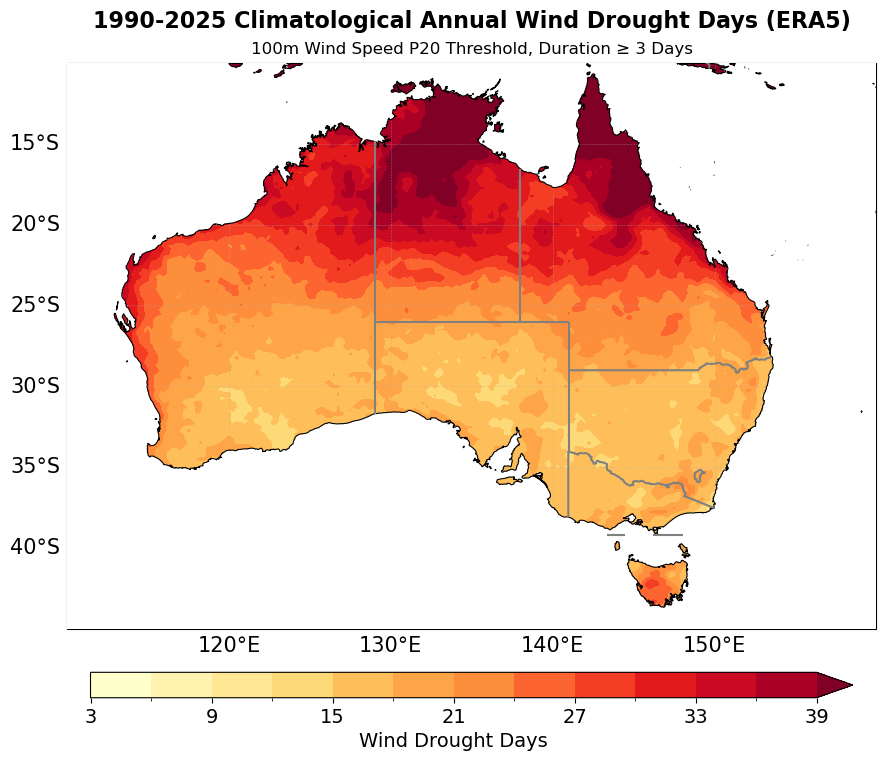

In [32]:
# =====================
# Plot variable
# =====================
days_plot = clim_days

# =====================
# Colormap
# =====================
cmap = plt.cm.YlOrRd.copy()

# values below first level
cmap.set_under("white")

levels = np.arange(3, 42, 3)

norm = mcolors.BoundaryNorm(
    levels,
    cmap.N,
    extend="max"
)

# =====================
# Figure
# =====================
fig = plt.figure(figsize=(10,8))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

# =====================
# Filled contours
# =====================
cf = ax.contourf(
    days_plot.longitude,
    days_plot.latitude,
    days_plot,
    levels=levels,
    cmap=cmap,
    norm=norm,
    extend="max",
    transform=ccrs.PlateCarree()
)

# =====================
# Ocean mask
# =====================
ax.add_feature(
    cfeature.OCEAN,
    facecolor="white",
    edgecolor="none",
    zorder=100
)

# =====================
# Coastline
# =====================
ax.coastlines(
    resolution="10m",
    linewidth=0.8,
    color="black",
    zorder=101
)

# =====================
# Australian state boundaries
# =====================
states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

ax.add_feature(
    states,
    edgecolor="grey",
    linewidth=1.5,
    zorder=102
)

# =====================
# Domain
# =====================
ax.set_extent(
    [110,160,-45,-10],
    crs=ccrs.PlateCarree()
)

# =====================
# Gridlines
# =====================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    linestyle="--",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {"size":15}
gl.ylabel_style = {"size":15}

# =====================
# Colorbar
# =====================
cbar = plt.colorbar(
    cf,
    orientation="horizontal",
    pad=0.06,
    shrink=0.8,
    aspect=30
)

cbar.set_label(
    "Wind Drought Days",
    fontsize=14
)

cbar.set_ticks(
    np.arange(3,42,6)
)

cbar.ax.tick_params(
    labelsize=14
)

# =====================
# Title
# =====================
ax.set_title(
    "1990-2025 Climatological Annual Wind Drought Days (ERA5)",
    fontsize=16,
    fontweight="bold",
    pad=25
)

ax.text(
    0.5,
    1.01,
    "100m Wind Speed P20 Threshold, Duration ≥ 3 Days",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="normal"
)


# =====================
# Save
# =====================
plt.tight_layout()

plt.savefig(
    "ERA5_P20_3day_climatological_drought_days.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()